# 02 — Análise Exploratória de Dados (EDA)

Este notebook realiza a análise exploratória completa do dataset de controle de qualidade,
buscando entender a distribuição dos parâmetros, identificar padrões e correlações,
e caracterizar o perfil de lotes aprovados vs. reprovados.

**Etapas:**
1. Carregamento e visão geral dos dados
2. Distribuição das variáveis numéricas
3. Análise por status do lote
4. Correlações
5. Análise por turno
6. Tendência temporal

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv('../data/raw/lotes_qc.csv', parse_dates=['data_producao'])
print(f"Shape: {df.shape}")
df.head()

Shape: (500, 11)


,lote,data_producao,turno,temp_processo,umidade_relativa,pressao_compressao,dureza_media,friabilidade,peso_medio,dissolucao,status_lote
0,LOT-0001,2023-01-01 00:00:00,C,25.48,49.99,10.48,109.95,0.979,507.08,89.50,APROVADO
1,LOT-0002,2023-01-01 12:00:00,A,24.98,43.57,12.80,109.67,0.783,503.87,90.19,APROVADO
2,LOT-0003,2023-01-02 00:00:00,A,23.78,48.80,12.81,112.83,0.738,499.21,89.44,APROVADO
3,LOT-0004,2023-01-02 12:00:00,B,26.23,43.54,12.46,112.41,0.607,501.54,93.55,APROVADO
4,LOT-0005,2023-01-03 00:00:00,B,25.34,44.70,10.81,110.59,0.864,497.00,85.77,APROVADO


## 1. Visão Geral dos Dados

In [2]:
print("=== Informações gerais ===")
df.info()
print("\n=== Valores ausentes ===")
print(df.isnull().sum())
print("\n=== Estatísticas descritivas ===")
df.describe().round(2)

=== Informações gerais ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   lote                500 non-null    object        
 1   data_producao       500 non-null    datetime64[ns]
 2   turno               500 non-null    object        
 3   temp_processo       500 non-null    float64       
 4   umidade_relativa    500 non-null    float64       
 5   pressao_compressao  500 non-null    float64       
 6   dureza_media        500 non-null    float64       
 7   friabilidade        500 non-null    float64       
 8   peso_medio          500 non-null    float64       
 9   dissolucao          500 non-null    float64       
 10  status_lote         500 non-null    object        
dtypes: datetime64[ns](1), float64(7), object(3)
memory usage: 43.1+ KB

=== Valores ausentes ===
lote                  0
data_producao     

,data_producao,temp_processo,umidade_relativa,pressao_compressao,dureza_media,friabilidade,peso_medio,dissolucao
count,500,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,2023-05-05 17:59:59.999999744,24.86,44.80,11.99,109.80,0.79,499.76,90.10
min,2023-01-01 00:00:00,20.49,29.15,8.19,99.65,0.32,486.46,81.65
25%,2023-03-04 09:00:00,23.90,41.67,11.18,107.08,0.69,496.26,88.01
50%,2023-05-05 18:00:00,24.89,45.04,11.98,109.96,0.79,499.68,89.98
75%,2023-07-07 03:00:00,25.80,48.32,12.77,112.36,0.90,503.44,92.10
max,2023-09-07 12:00:00,29.73,56.94,15.74,124.69,1.26,514.68,98.77
std,NaN,1.50,4.78,1.21,4.01,0.16,5.06,2.92


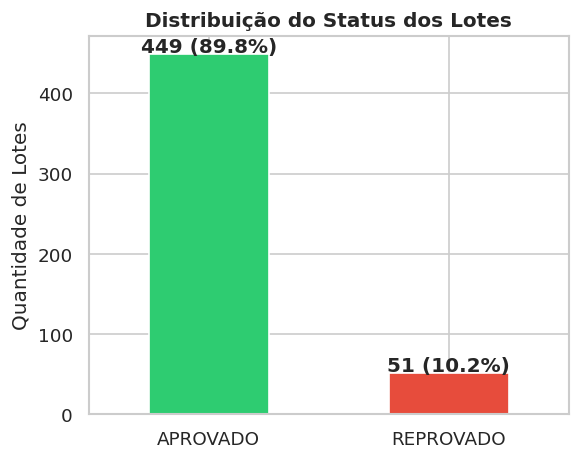

In [3]:
# Distribuição da variável alvo
fig, ax = plt.subplots(figsize=(5, 4))
contagem = df['status_lote'].value_counts()
cores = ['#2ecc71', '#e74c3c']
contagem.plot(kind='bar', ax=ax, color=cores, edgecolor='white', width=0.5)
ax.set_title('Distribuição do Status dos Lotes', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Quantidade de Lotes')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(contagem):
    ax.text(i, v + 3, f'{v} ({v/len(df):.1%})', ha='center', fontweight='bold')
plt.tight_layout()
os.makedirs('../reports/figures', exist_ok=True)
plt.savefig('../reports/figures/01_distribuicao_status.png')
plt.show()

## 2. Distribuição dos Parâmetros por Status do Lote

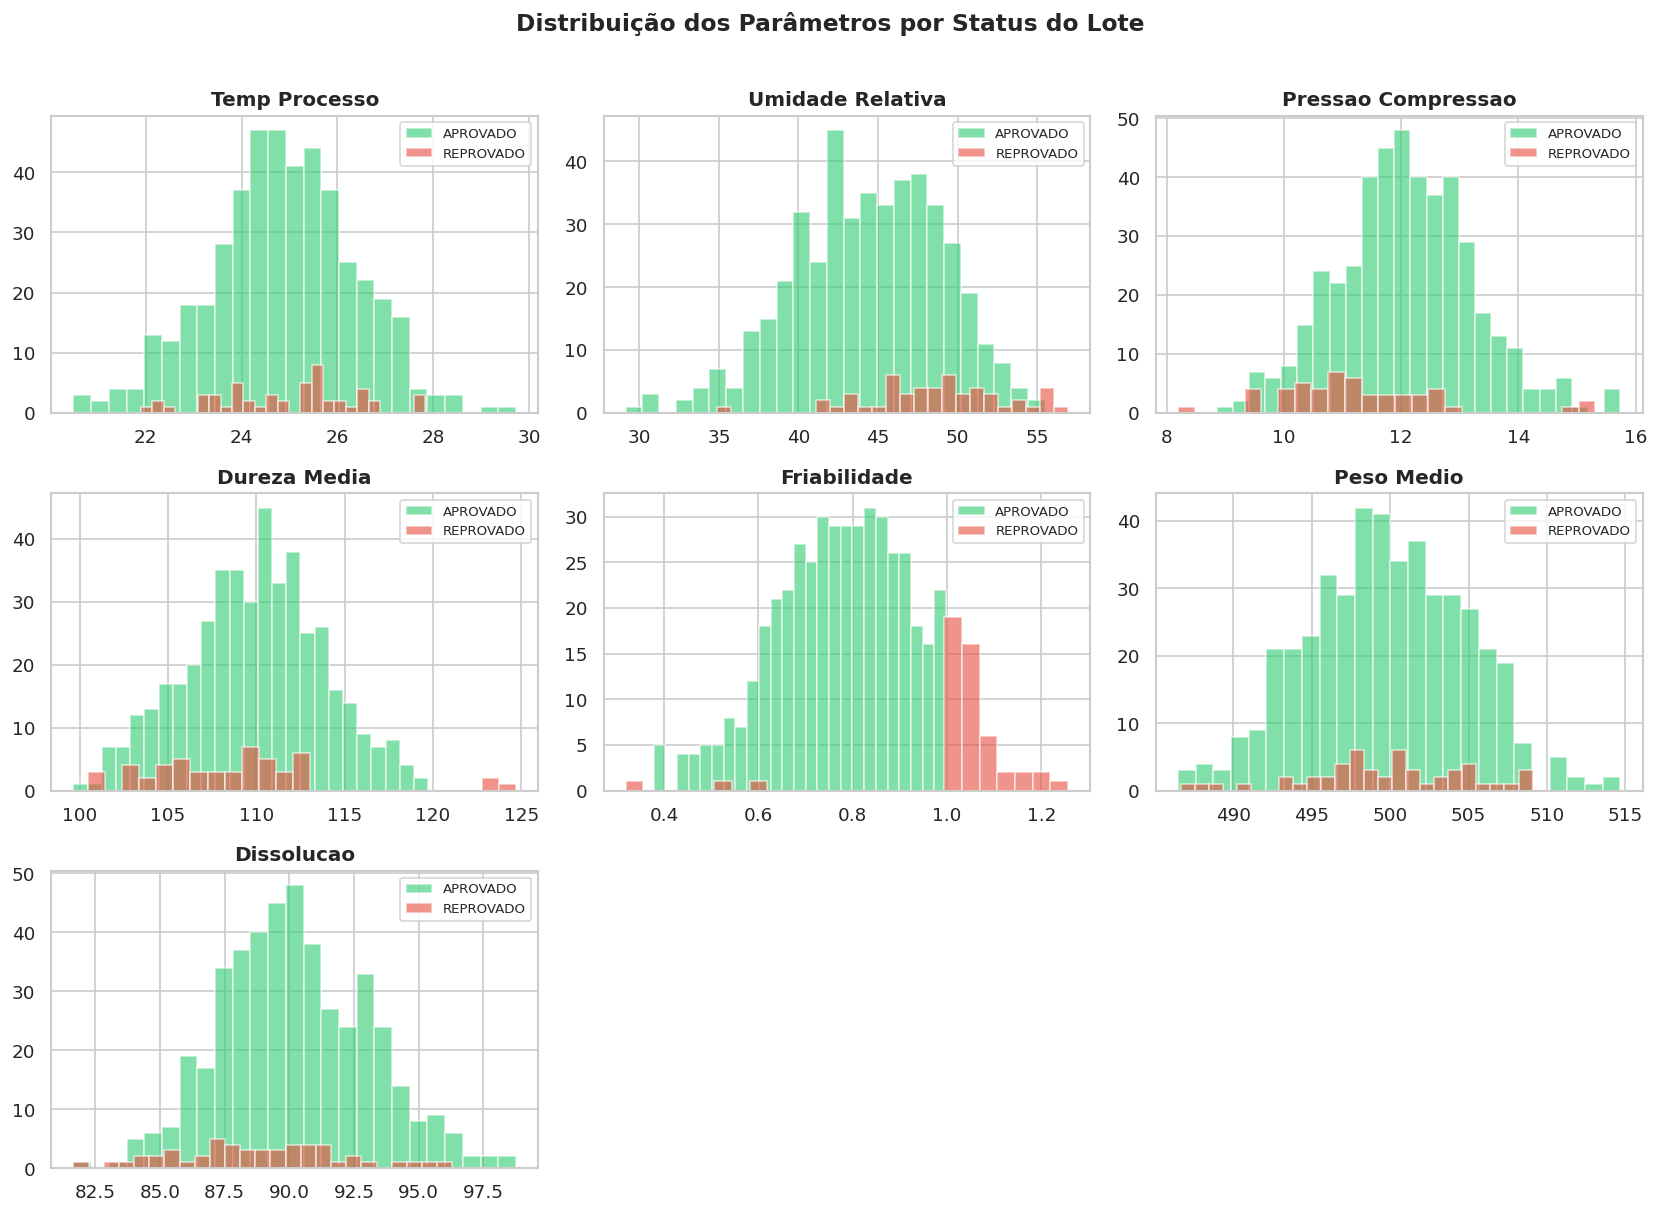

In [4]:
variaveis = ['temp_processo', 'umidade_relativa', 'pressao_compressao',
             'dureza_media', 'friabilidade', 'peso_medio', 'dissolucao']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(variaveis):
    for status, cor in [('APROVADO', '#2ecc71'), ('REPROVADO', '#e74c3c')]:
        subset = df[df['status_lote'] == status][var]
        axes[i].hist(subset, bins=25, alpha=0.6, color=cor, label=status, edgecolor='white')
    axes[i].set_title(var.replace('_', ' ').title(), fontweight='bold')
    axes[i].legend(fontsize=8)

# Desligar subplots extras
for j in range(len(variaveis), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribuição dos Parâmetros por Status do Lote', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/02_distribuicao_parametros.png', bbox_inches='tight')
plt.show()

## 3. Matriz de Correlação

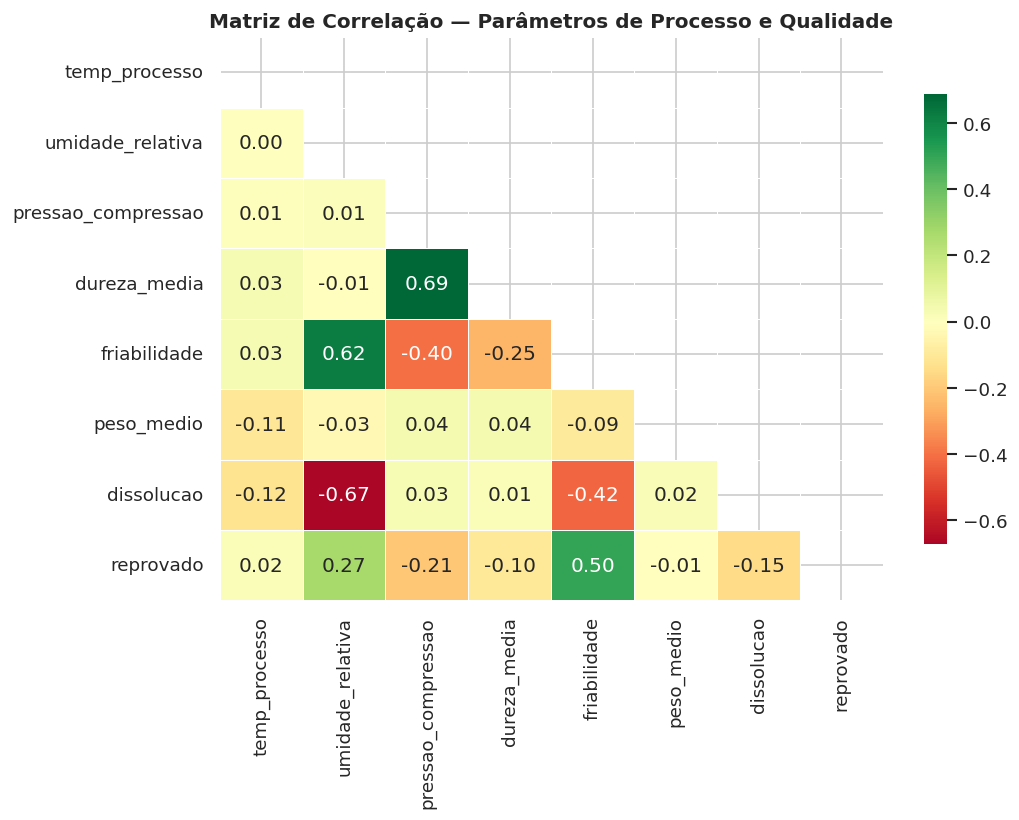


Correlação com 'reprovado':
friabilidade          0.500
umidade_relativa      0.269
pressao_compressao   -0.206
dissolucao           -0.148
dureza_media         -0.101
temp_processo         0.018
peso_medio           -0.007
Name: reprovado, dtype: float64


In [5]:
# Adiciona coluna numérica para correlação com status
df['reprovado'] = (df['status_lote'] == 'REPROVADO').astype(int)

corr = df[variaveis + ['reprovado']].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlação — Parâmetros de Processo e Qualidade', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/03_correlacao.png')
plt.show()

print("\nCorrelação com 'reprovado':")
print(corr['reprovado'].drop('reprovado').sort_values(key=abs, ascending=False).round(3))

## 4. Taxa de Reprovação por Turno

       total  reprovados  taxa_reprovacao
turno                                    
A        166          18             10.8
B        162          20             12.3
C        172          13              7.6


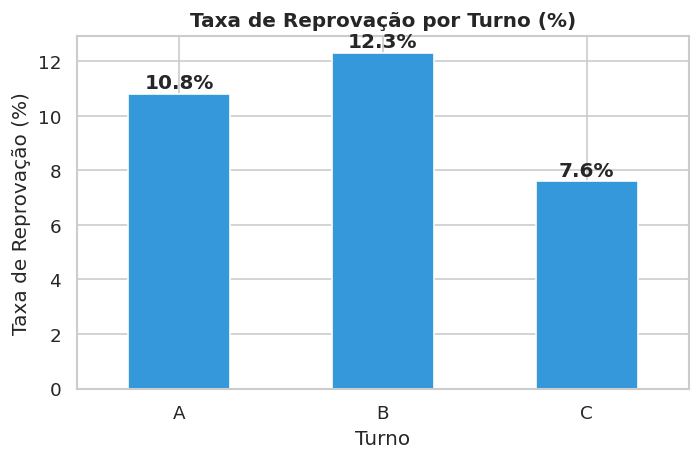

In [6]:
turno_stats = df.groupby('turno').agg(
    total=('lote', 'count'),
    reprovados=('reprovado', 'sum')
).assign(taxa_reprovacao=lambda x: x['reprovados'] / x['total'] * 100).round(1)

print(turno_stats)

fig, ax = plt.subplots(figsize=(6, 4))
turno_stats['taxa_reprovacao'].plot(kind='bar', ax=ax, color='#3498db', edgecolor='white', width=0.5)
ax.set_title('Taxa de Reprovação por Turno (%)', fontweight='bold')
ax.set_xlabel('Turno')
ax.set_ylabel('Taxa de Reprovação (%)')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(turno_stats['taxa_reprovacao']):
    ax.text(i, v + 0.2, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/04_reprovacao_turno.png')
plt.show()

## 5. Tendência Temporal — Taxa de Reprovação Mensal

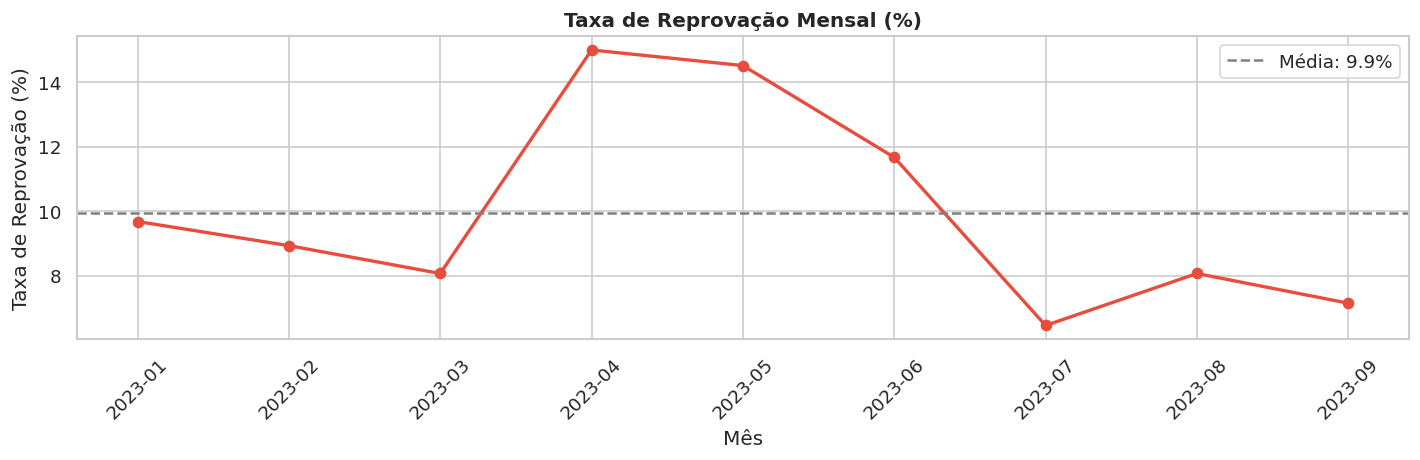

In [7]:
df['mes'] = df['data_producao'].dt.to_period('M')
mensal = df.groupby('mes').agg(
    total=('lote', 'count'),
    reprovados=('reprovado', 'sum')
).assign(taxa=lambda x: x['reprovados'] / x['total'] * 100)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(mensal.index.astype(str), mensal['taxa'], marker='o', color='#e74c3c', linewidth=2)
ax.axhline(mensal['taxa'].mean(), color='gray', linestyle='--', label=f'Média: {mensal["taxa"].mean():.1f}%')
ax.set_title('Taxa de Reprovação Mensal (%)', fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Taxa de Reprovação (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/05_tendencia_mensal.png')
plt.show()

## Conclusões da EDA

- **Friabilidade e dissolução** são as duas variáveis de CQ que apresentam as maiores correlações com reprovação de lotes
- **Pressão de compressão** influencia diretamente dureza e friabilidade — variável de processo crítica
- **Turnos** apresentam taxas de reprovação similares, sem desvio significativo entre equipes
- A tendência temporal será investigada no notebook de modelagem

➡️ Próximo passo: **Notebook 03 — Modelo Preditivo**